In [ ]:
# https://drive.google.com/file/d/1KBlnMjAHDz0iSOWEfm69UwOpXdlwe7s4/view?usp=sharing pref.zip

In [ ]:
import os
import gdown
import zipfile
from google.colab import drive

# Подключаем Google Диск
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ссылка на архив
url = 'https://drive.google.com/uc?id=1KBlnMjAHDz0iSOWEfm69UwOpXdlwe7s4'
output = 'pref.zip'

# Загрузка архива
gdown.download(url, output, quiet=False)

# Распаковка архива
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('pref')

# Проверка содержимого
classes = os.listdir('pref')
print(classes)

Downloading...
From (original): https://drive.google.com/uc?id=1KBlnMjAHDz0iSOWEfm69UwOpXdlwe7s4
From (redirected): https://drive.google.com/uc?id=1KBlnMjAHDz0iSOWEfm69UwOpXdlwe7s4&confirm=t&uuid=583c8191-c0ed-46fc-9484-e4ad60670ee1
To: /content/pref.zip
100%|██████████| 3.81G/3.81G [01:04<00:00, 58.6MB/s]


['pref']


In [ ]:
!ls /content/pref/pref/

 chern_toch  'non defects'   prigar   vozd_puz


In [ ]:
# методы для отрисовки изображений
from PIL import Image

# Для отрисовки графиков
import matplotlib.pyplot as plt

# Для генерации случайных чисел
import random

# Библиотека работы с массивами
import numpy as np

# для разделения выборок
from sklearn.model_selection import train_test_split

# для создания сети
from tensorflow.keras.models import Sequential

# для создания слоев
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

# для работы с изображениями
from tensorflow.keras.preprocessing import image

# оптимизатор
from tensorflow.keras.optimizers import Adam

# модуль для отсчета времени
import time

In [ ]:
IMAGE_PATH = '/content/pref/pref/'

In [ ]:
# Получение списка папок, находящемуся по адресу в скобках
os.listdir(IMAGE_PATH)

['chern_toch', 'non defects', 'prigar', 'vozd_puz']

In [ ]:
# Определение списка имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 4, метки классов: ['chern_toch', 'non defects', 'prigar', 'vozd_puz']


In [ ]:
# Получения списка файлов для каждого класса

for cls in CLASS_LIST:
    print(cls, ':', os.listdir(f'{IMAGE_PATH}{cls}/'))

chern_toch : ['HT-SUA501GC-T1V-C-Snapshot-20250823-133227-784-443107051057.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-123654-427-409773476853.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133228-062-443109824898.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133131-334-442542550989.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133641-794-445647155248.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133130-996-442539173667.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133515-420-444783406773.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133451-405-444543265887.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133218-636-443015569014.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-123652-470-409753896209.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133227-471-443103924297.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133126-795-442497167566.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-123625-688-409486079895.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-123512-097-408750168806.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133707-405-

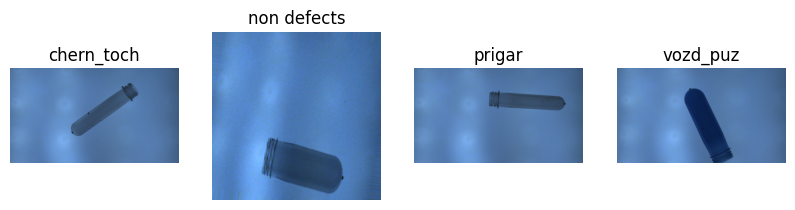

In [ ]:
# Создание заготовки для изображений всех классов
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(10, 5))

# Для всех номеров классов:
for i in range(CLASS_COUNT):

    # Формирование пути к папке содержимого класса
    car_path = f'{IMAGE_PATH}{CLASS_LIST[i]}/'

    # Выбор случайного фото из i-го класса
    img_path = car_path + random.choice(os.listdir(car_path))

    # Отображение фотографии (подробнее будет объяснено далее)
    axs[i].set_title(CLASS_LIST[i])
    axs[i].imshow(Image.open(img_path))
    axs[i].axis('off')

# Отрисовка всего полотна
plt.show()

In [ ]:
data_files = []                           # Cписок путей к файлам картинок
data_labels = []                          # Список меток классов, соответствующих файлам

for class_label in range(CLASS_COUNT):    # Для всех классов по порядку номеров (их меток)
    class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен
    class_path = IMAGE_PATH + class_name  # Формирование полного пути к папке с изображениями класса
    class_files = os.listdir(class_path)  # Получение списка имен файлов с изображениями текущего класса
    print(f'Размер класса {class_name} составляет {len(class_files)} фото')

    # Добавление к общему списку всех файлов класса с добавлением родительского пути
    data_files += [f'{class_path}/{file_name}' for file_name in class_files]

    # Добавление к общему списку меток текущего класса - их ровно столько, сколько файлов в классе
    data_labels += [class_label] * len(class_files)

print()
print('Общий размер базы для обучения:', len(data_labels))

Размер класса chern_toch составляет 178 фото
Размер класса non defects составляет 1212 фото
Размер класса prigar составляет 187 фото
Размер класса vozd_puz составляет 210 фото

Общий размер базы для обучения: 1787


In [ ]:
# Задание единых размеров изображений
IMG_WIDTH = 128                           # Ширина изображения
IMG_HEIGHT = 64                           # Высота изображения

In [ ]:
# перевод изображений в тензоры
data_images = []                          # Пустой список для данных изображений

for file_name in data_files:
    # Открытие и смена размера изображения
    img = Image.open(file_name).resize((IMG_WIDTH, IMG_HEIGHT))
    img_np = np.array(img)                # Перевод в numpy-массив
    data_images.append(img_np)            # Добавление изображения в виде numpy-массива к общему списку

x_data = np.array(data_images)            # Перевод общего списка изображений в numpy-массив
y_data = np.array(data_labels)            # Перевод общего списка меток класса в numpy-массив

print(f'В массив собрано {len(data_images)} фотографий следующей формы: {img_np.shape}')
print(f'Общий массив данных изображений следующей формы: {x_data.shape}')
print(f'Общий массив меток классов следующей формы: {y_data.shape}')

В массив собрано 1787 фотографий следующей формы: (64, 128, 3)
Общий массив данных изображений следующей формы: (1787, 64, 128, 3)
Общий массив меток классов следующей формы: (1787,)


array([[[ 79, 112, 158],
        [ 79, 116, 159],
        [ 82, 120, 167],
        ...,
        [ 60,  88, 123],
        [ 59,  86, 121],
        [ 57,  85, 119]],

       [[ 79, 113, 157],
        [ 81, 117, 161],
        [ 84, 120, 167],
        ...,
        [ 60,  89, 122],
        [ 59,  87, 121],
        [ 58,  86, 120]],

       [[ 79, 114, 159],
        [ 82, 117, 161],
        [ 85, 121, 167],
        ...,
        [ 61,  90, 125],
        [ 60,  88, 124],
        [ 58,  87, 123]],

       ...,

       [[ 85, 123, 170],
        [ 88, 125, 172],
        [ 89, 127, 176],
        ...,
        [ 68,  99, 138],
        [ 67,  97, 136],
        [ 65,  96, 132]],

       [[ 86, 124, 169],
        [ 88, 126, 175],
        [ 89, 128, 176],
        ...,
        [ 69, 100, 141],
        [ 66,  98, 134],
        [ 65,  96, 132]],

       [[ 88, 125, 172],
        [ 90, 128, 178],
        [ 91, 131, 181],
        ...,
        [ 70, 101, 143],
        [ 68,  98, 138],
        [ 67,  97, 136]]], dtype=uint8)
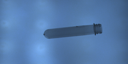

In [ ]:
# вывод первого изображения (трехмерный тензор)
x_data[0]

In [ ]:
# Создание модели последовательной архитектуры
model = Sequential()

In [ ]:
# Первый сверточный блок
model.add(Conv2D(256, (3, 3), name='First_C', padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))  # (64,128,3) --> (64,128,256) меняется кол-во фильтров
model.add(BatchNormalization(name='First_B'))  # (64,128,256) --> (64,128,256) нет изменений

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Второй сверточный блок
model.add(Conv2D(256, (3, 3), name='Second_C', padding='same', activation='relu'))  # (64,128,256) --> (64,128,256) нет изменений
model.add(MaxPooling2D(pool_size=(3, 3), name='Second_M'))  # сжимает размер в три раза, с потерей, т.к. padding='valid', глубина не изм. (64,128,256) --> (21,42,256)

In [ ]:
# Третий сверточный блок
model.add(Conv2D(256, (3, 3), name='Third_C', padding='same', activation='relu'))  # (21,42,256) --> (21,42,256) нет изменений
model.add(BatchNormalization(name='Third_B'))  # (21,42,256) --> (21,42,256) нет изменений
model.add(Dropout(0.2, name='Third_D'))  # (21,42,256) --> (21,42,256) нет изменений

In [ ]:
# Четвертый сверточный блок
model.add(Conv2D(256, (3, 3), name='Fourth_F_Unique', padding='same', activation='relu'))  # (21,42,256) --> (21,42,256) нет изменений
model.add(MaxPooling2D(pool_size=(3, 3), name='Fourth_M_Unique'))  # сжимает размер в три раза, хотя padding='valid', потерь нет, т.к. делится кратно, глубина не изм. (21,42,256) --> (7,14,256)
model.add(Dropout(0.2, name='Fourth_D_Unique'))  # (7,14,256) --> (7,14,256) нет изменений

In [ ]:
# Пятый сверточный блок
model.add(Conv2D(512, (3, 3), name='Fifth_D', padding='same', activation='relu'))  # (7,14,256) --> (7,14,512) меняется количество фильтров
model.add(BatchNormalization(name='Fifth_B'))  # (7,14,512) --> (7,14,512) нет изменений

In [ ]:
# Шестой сверточный блок
model.add(Conv2D(1024, (3, 3), name='Sixth_C', padding='same', activation='relu'))  # (7,14,1024) --> (7,14,1024) меняется кол-во фильтров
model.add(MaxPooling2D(pool_size=(3, 3), name='Sixth_M'))  # сжимает размер в три раза, с потерей, т.к. padding='valid', глубина не изм. (7,14,1024) --> (2,4,1024)
model.add(Dropout(0.2, name='Sixth_D'))  # (2,4,1024) --> (2,4,1024) нет изменений

In [ ]:
# Блок классификации
#model.add(Flatten(name='Class_11'))  # слой преобразования многомерных данных в одномерные (2,4,1024) --> (2*4*1024) --> (8192)
#model.add(Dense(2048, activation='relu', name='Class_12'))  # полносвязный слой, меняется кол-во нейронов (8192) --> (2048)
# model.add(Dense(4096, activation='relu', name='Class_3'))  # полносвязный слой, меняется кол-во нейронов (2048) --> (4096)
#model.add(Dense(CLASS_COUNT, activation='softmax', name='Class_13'))  # выходной полносвязный слой, кол-во нейронов = количество классов (4096) --> (3)

In [ ]:
# Блок классификации
model.add(Flatten(name='Class_1'))  # слой преобразования многомерных данных в одномерные (2,4,1024) --> (2*4*1024) --> (8192)
model.add(Dense(2048, activation='relu', name='Class_2'))  # полносвязный слой, меняется кол-во нейронов (8192) --> (2048)
model.add(Dense(4096, activation='relu', name='Class_3'))  # полносвязный слой, меняется кол-во нейронов (2048) --> (4096)
model.add(Dense(CLASS_COUNT, activation='softmax', name='Class_4'))  # выходной полносвязный слой, кол-во нейронов = количество классов (4096) --> (количество классов)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ First_C (Conv2D)                │ (None, 64, 128, 256)   │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ First_B (BatchNormalization)    │ (None, 64, 128, 256)   │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Second_C (Conv2D)               │ (None, 64, 128, 256)   │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Second_M (MaxPooling2D)         │ (None, 21, 42, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_C (Conv2D)                │ (None, 21, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_B (BatchNormalization)    │ (None, 21, 42, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_D (Dropout)               │ (None, 21, 42, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_F_Unique (Conv2D)        │ (None, 21, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_M_Unique (MaxPooling2D)  │ (None, 7, 14, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_D_Unique (Dropout)       │ (None, 7, 14, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fifth_D (Conv2D)                │ (None, 7, 14, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fifth_B (BatchNormalization)    │ (None, 7, 14, 512)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sixth_C (Conv2D)                │ (None, 7, 14, 1024)    │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sixth_M (MaxPooling2D)          │ (None, 2, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sixth_D (Dropout)               │ (None, 2, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_1 (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_2 (Dense)                 │ (None, 2048)           │    16,779,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_3 (Dense)                 │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_4 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,869,636 (125.39 MB)

 Trainable params: 32,867,588 (125.38 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Компиляция модели
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

In [ ]:
# Разделение данных на обучающую и тестовую выборки
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

In [ ]:
# Определение колбэков
model_checkpoint = ModelCheckpoint(filepath='model_best.h5', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=2, verbose=1)

In [ ]:
# Обучение модели и сохранение истории
history = model.fit(x_train,  # Обучающая выборка
                    y_train,  # Метки обучающей выборки
                    validation_data=(x_test, y_test),  # Тестовая выборка для валидации
                    shuffle=True,
                    batch_size=25,
                    epochs=30,
                    verbose=1,
                    callbacks=[model_checkpoint, reduce_lr])  # Добавление колбэков

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6323 - loss: 1.6789
Epoch 1: val_loss improved from inf to 2.54575, saving model to model_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 51s 480ms/step - accuracy: 0.6343 - loss: 1.6651 - val_accuracy: 0.1285 - val_loss: 2.5457 - learning_rate: 1.0000e-04
Epoch 2/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8655 - loss: 0.3677
Epoch 2: val_loss improved from 2.54575 to 0.43481, saving model to model_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.8656 - loss: 0.3661 - val_accuracy: 0.7961 - val_loss: 0.4348 - learning_rate: 1.0000e-04
Epoch 3/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9069 - loss: 0.2337
Epoch 3: val_loss did not improve from 0.43481
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.9072 - loss: 0.2334 - val_accuracy: 0.7291 - val_loss: 1.0293 - learning_rate: 1.0000e-04
Epoch 4/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9005 - loss: 0.2262
Epoch 4: val_loss did not improve from 0.43481

Epoch 4: ReduceLROnPlateau reducing learning rate to 5.999999848427251e-05.
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9011 - loss: 0.2250 - val_accuracy: 0.7402 - val_loss: 0.9230 - learning_rate: 1.0000e-04
Epoch 5/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9305 - loss: 0.1518
Epoch 5: val_loss did not improve from 0.43481
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.9309 - loss: 0.1511 - val_accu

58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - accuracy: 0.9888 - loss: 0.0319 - val_accuracy: 0.8883 - val_loss: 0.3924 - learning_rate: 1.2960e-05
Epoch 13/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9882 - loss: 0.0317
Epoch 13: val_loss improved from 0.39236 to 0.20763, saving model to model_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - accuracy: 0.9881 - loss: 0.0318 - val_accuracy: 0.9162 - val_loss: 0.2076 - learning_rate: 1.2960e-05
Epoch 14/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9839 - loss: 0.0334
Epoch 14: val_loss did not improve from 0.20763
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.9839 - loss: 0.0333 - val_accuracy: 0.9134 - val_loss: 0.2407 - learning_rate: 1.2960e-05
Epoch 15/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9925 - loss: 0.0261
Epoch 15: val_loss improved from 0.20763 to 0.19427, saving model to model_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.9925 - loss: 0.0261 - val_accuracy: 0.9274 - val_loss: 0.1943 - learning_rate: 1.2960e-05
Epoch 16/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9977 - loss: 0.0153
Epoch 16: val_loss did not improve from 0.19427
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9976 - loss: 0.0155 - val_accuracy: 0.9078 - val_loss: 0.3340 - learning_rate: 1.2960e-05
Epoch 17/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9985 - loss: 0.0171
Epoch 17: val_loss did not improve from 0.19427

Epoch 17: ReduceLROnPlateau reducing learning rate to 7.775999620207585e-06.
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9984 - loss: 0.0172 - val_accuracy: 0.9162 - val_loss: 0.2940 - learning_rate: 1.2960e-05
Epoch 18/30
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9973 - loss: 0.0150
Epoch 18: val_loss did not improve from 0.19427
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9973 - loss: 0.0150 - v

In [ ]:
scores = model.evaluate(x_data,
                        y_data,
                        verbose=1
                        )
print('Процент верных ответов на тестовых данных:', round(scores[1],2) * 100, '%')

56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.9848 - loss: 0.0434
Процент верных ответов на тестовых данных: 96.0 %


In [ ]:
# Оценка модели на тестовой выборке
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f'Тестовая точность: {test_accuracy:.4f}')
print(f'Тестовая потеря: {test_loss:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.9381 - loss: 0.2049
Тестовая точность: 0.9302
Тестовая потеря: 0.2183


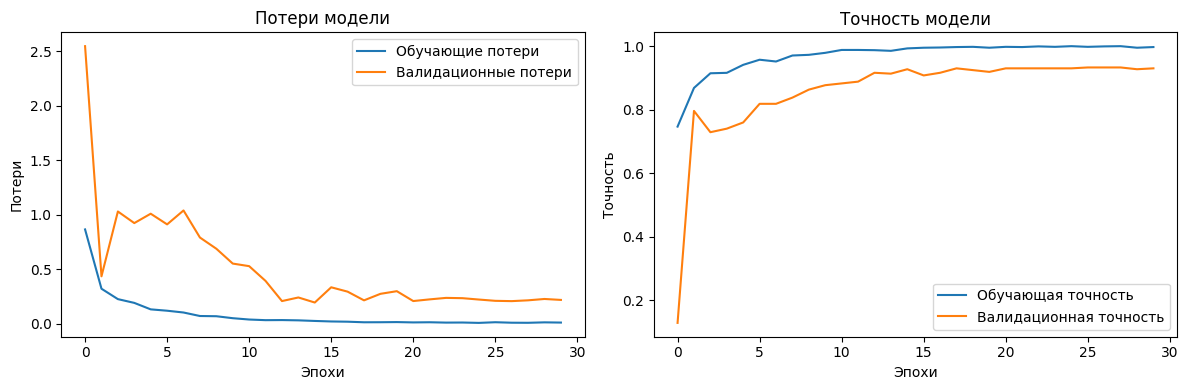

In [ ]:
# Визуализация процесса обучения
plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Обучающие потери')
plt.plot(history.history['val_loss'], label='Валидационные потери')
plt.title('Потери модели')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Обучающая точность')
plt.plot(history.history['val_accuracy'], label='Валидационная точность')
plt.title('Точность модели')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Получение предсказаний
predictions = model.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step


In [ ]:
# Определение класса с максимальной вероятностью для каждого изображения
predicted_classes = np.argmax(predictions, axis=1)

In [ ]:
# Выбор одного изображения из каждого класса
unique_classes = np.unique(predicted_classes)
images_per_class = []
for cls in unique_classes:
    class_indices = np.where(predicted_classes == cls)[0]
    if len(class_indices) > 0:
        images_per_class.append(x_test[class_indices[0]])